# Distribuzioni di probabilità a più dimensioni

Si può generalizzare la densità di probabilità, definita per una variabile $x$ come:

$\displaystyle f(x) = \frac{\mathrm{d}P(x)}{\mathrm{d}x}$

Passando a due (o anche più) dimensioni $(x,y)$ come segue:

$\displaystyle f(x,y) = \frac{\mathrm{d}P(x,y)}{\mathrm{d}x\,\mathrm{d}y}$

Questa volta, $\mathrm{d}x\,\mathrm{d}y$ rappresenta l'elemeno di superficie in due dimensioni nelle coordinate $(x,y)$.

In [1]:
import numpy as np
from scipy.stats import norm

Definiamo la funzione:
$f(x,y) = g(x)g(y)$
dove $g$ è una gaussiana con media 0 e deviazione standard 1:

In [2]:
def f(x, y):
    return norm.pdf(x)*norm.pdf(y)

Definiamo una griglia $100\times 100$ che servirà per graficare la PDF in più dimensioni.

In [3]:
nptx, npty = 101, 101
x_p = np.linspace(-5, 5, nptx)
y_p = np.linspace(-5, 5, npty)
x_p

array([-5. , -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1, -4. ,
       -3.9, -3.8, -3.7, -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. , -2.9,
       -2.8, -2.7, -2.6, -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9, -1.8,
       -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7,
       -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,
        0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5,
        1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,
        2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,
        3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,
        4.9,  5. ])

Con ```numpy``` si può definire una [```meshgrid```](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) che ci aiuterà nell'operazione di plot. In  pratica, per ogni punto sulla griglia definiamo quali sono le sue coordinate $x$ e $y$, e poi calcoliamo il valore $z$ come $f(x,y)$:

In [4]:
x, y = np.meshgrid(x_p, y_p)

In [5]:
x

array([[-5. , -4.9, -4.8, ...,  4.8,  4.9,  5. ],
       [-5. , -4.9, -4.8, ...,  4.8,  4.9,  5. ],
       [-5. , -4.9, -4.8, ...,  4.8,  4.9,  5. ],
       ...,
       [-5. , -4.9, -4.8, ...,  4.8,  4.9,  5. ],
       [-5. , -4.9, -4.8, ...,  4.8,  4.9,  5. ],
       [-5. , -4.9, -4.8, ...,  4.8,  4.9,  5. ]], shape=(101, 101))

In [6]:
y

array([[-5. , -5. , -5. , ..., -5. , -5. , -5. ],
       [-4.9, -4.9, -4.9, ..., -4.9, -4.9, -4.9],
       [-4.8, -4.8, -4.8, ..., -4.8, -4.8, -4.8],
       ...,
       [ 4.8,  4.8,  4.8, ...,  4.8,  4.8,  4.8],
       [ 4.9,  4.9,  4.9, ...,  4.9,  4.9,  4.9],
       [ 5. ,  5. ,  5. , ...,  5. ,  5. ,  5. ]], shape=(101, 101))

In [7]:
z = f(x, y)

In [8]:
z

array([[2.21033492e-12, 3.62605054e-12, 5.88934066e-12, ...,
        5.88934066e-12, 3.62605054e-12, 2.21033492e-12],
       [3.62605054e-12, 5.94852952e-12, 9.66145299e-12, ...,
        9.66145299e-12, 5.94852952e-12, 3.62605054e-12],
       [5.88934066e-12, 9.66145299e-12, 1.56918905e-11, ...,
        1.56918905e-11, 9.66145299e-12, 5.88934066e-12],
       ...,
       [5.88934066e-12, 9.66145299e-12, 1.56918905e-11, ...,
        1.56918905e-11, 9.66145299e-12, 5.88934066e-12],
       [3.62605054e-12, 5.94852952e-12, 9.66145299e-12, ...,
        9.66145299e-12, 5.94852952e-12, 3.62605054e-12],
       [2.21033492e-12, 3.62605054e-12, 5.88934066e-12, ...,
        5.88934066e-12, 3.62605054e-12, 2.21033492e-12]], shape=(101, 101))

Quindi passiamo tutto a ```matplotlib``` per graficare in 3D. Esistono vari tipi di grafico, vedremo il *wireframe* e una superficie colorata.

Per approfondimenti:
* [Three-Dimensional Plotting in Matplotlib](https://jakevdp.github.io/PythonDataScienceHandbook/04.12-three-dimensional-plotting.html)


In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib import cm

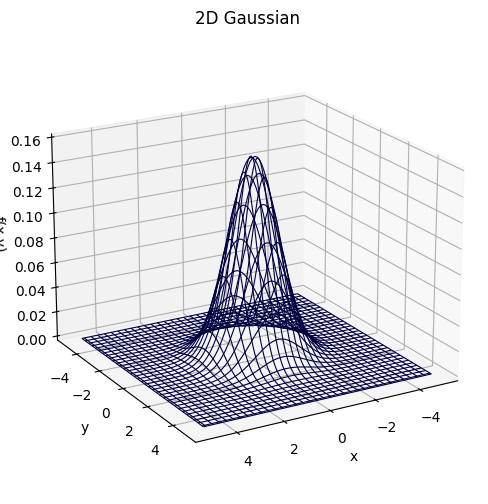

In [10]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
ax.view_init(20, 60)
ax.plot_wireframe(x, y, z, color='#000040', linewidth=0.8)
ax.set_title('2D Gaussian')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.show()

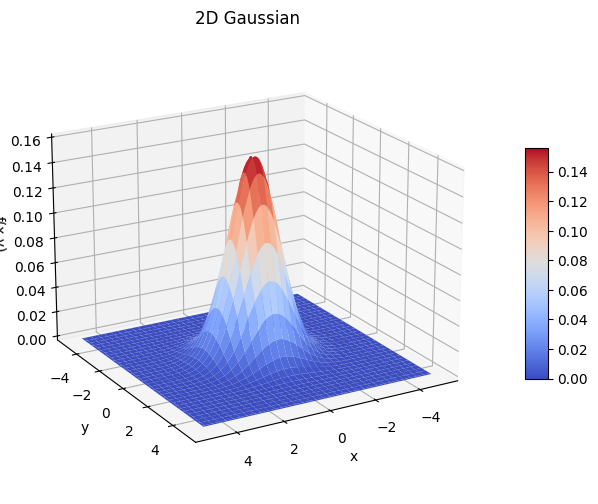

In [11]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection='3d')
ax.view_init(20, 60)
surf = ax.plot_surface(x, y, z, cmap=cm.coolwarm)
ax.set_title('2D Gaussian')
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.show()

Si può proiettare anche la PDF in due dimensioni mostrando i valori della PDF o come mappa colorata, oppure come una serie di **curve equiprobabili**.

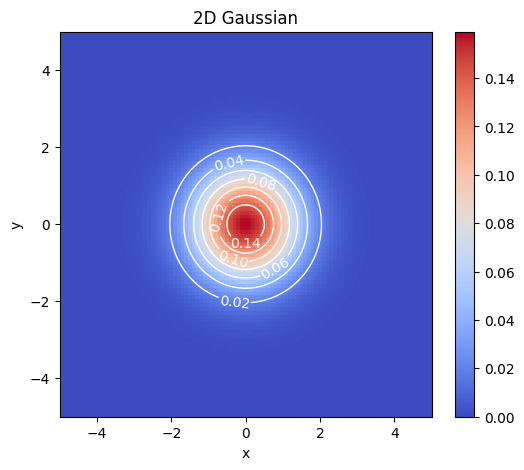

In [12]:
figure, ax = plt.subplots(figsize=(6, 5))
col = ax.pcolormesh(x, y, z, cmap=cm.coolwarm, shading='auto')
con = ax.contour(x, y, z, np.linspace(0, 0.14, 8), colors='white', linewidths=1)
ax.clabel(con, inline=1, fontsize=10)
ax.set_title('2D Gaussian')
ax.axis([x.min(), x.max(), y.min(), y.max()])
ax.set_xlabel('x')
ax.set_ylabel('y')
figure.colorbar(col)
plt.show()

## Distribuzioni a tre o più dimensioni

Analogamente a tre dimensioni si può definire:

$\displaystyle f(x,y,z) = \frac{\mathrm{d}P(x,y,z)}{\mathrm{d}x\,\mathrm{d}y\,\mathrm{d}z}$

Una PDF a $n$ dimensioni è definita analogamente:

$\displaystyle f(x_1,\cdots,x_n) = \frac{\mathrm{d}P(x_1,\cdots,x_n)}{\mathrm{d}x_1\cdots \mathrm{d}x_n}$


Resta la difficoltà di graficare oltre le due dimensioni.

# Distribuzioni marginali

Le distribuzioni di probabilità per le variabili $x$ e $y$ si ottengono integrando sull'altra (sulle altre, per più di due variabili) variabile:

$\displaystyle f_x(x) = \int_{-\infty}^{+\infty} f(x,y)\,\mathrm{d}y$

$\displaystyle f_y(y) = \int_{-\infty}^{+\infty} f(x,y)\,\mathrm{d}x$

$f_x$ e $f_y$ rappresentano le distribuzioni di probabilità di ciascuna variabile separatamente.

In sostanza, la distribuzione di probabilità di una sola variabile si ottiene *proiettando* la PDF su quella variabile.

Quando considereremo il problema generale del cambio di variabili, vedremo che le distribuzioni marginali si ottengono come caso particolare della trasformazione $\varphi: (x,y)\in X\times Y \mapsto y=\varphi(x)\in Y$.

Più in generale, si può ottenere la distribuzione marginale per un sottoinsieme di variabili:

$\displaystyle f_{1\cdots k}(x_1,\cdots, x_k) = \int f(x_1,\cdots, x_n)\,\mathrm{d}x_{k+1}\cdots\mathrm{d}x_n$


# Distribuzione condizionata

Fissato un valore $x=x_0$, la PDF di $y$ si può calcolare normalizzando la PDF che viene calcolata per il valore di $x_0$ fissato:

$\displaystyle f(y|x_0) = \frac{f(x_0,y)}{\int f(x_0,y)\,\mathrm{d}y} = 
\frac{f(x_0,y)}{f_x(x_0)}
$

Nel grafico seguente mostriamo la distribuzione condizionata **non** normalizzata, per motivi grafici. Ossia, mostriamo $f(x_0,y)$ e non $f(y|x_0)$, che andrebbe moltiplicata per un fattore di normalizzazione $1/f_x(x_0)$.

Risulta quindi:

$\displaystyle \int_{-\infty}^{+\infty}f(y|x_0)\,\mathrm{d}y = 1$

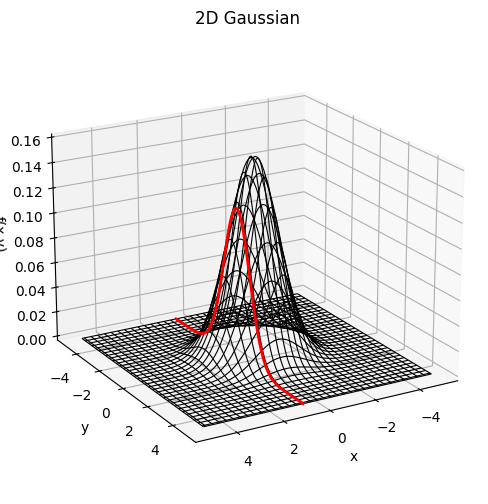

In [13]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
ax.view_init(20, 60)
ax.plot_wireframe(x, y, z, color='black', linewidth=0.8)
ax.plot([0.75]*nptx, y_p, f(0.75, y_p), color='red', zorder=10, linewidth=2)
ax.set_title('2D Gaussian')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.show()

Analogamente, fissato un valore $y=y_0$, la PDF di $x$ si può calcolare normalizzando la PDF che viene calcolata per il valore di $y_0$ fissato:

$\displaystyle  f(x|y_0) = \frac{f(x,y_0)}{\int f(x,y_0)\,\mathrm{d}x} =
\frac{f(x,y_0)}{f_y(y_0)}
$

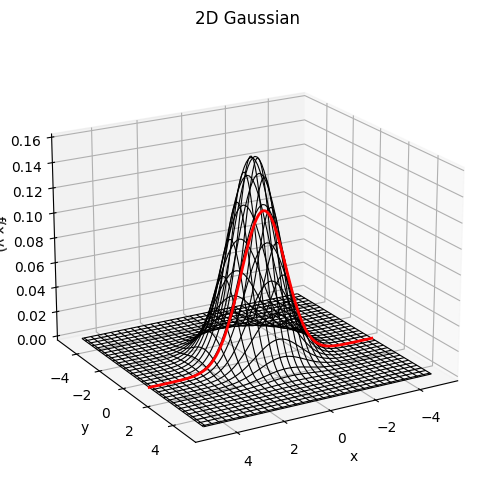

In [14]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
ax.view_init(20, 60)
ax.plot_wireframe(x, y, z, color='black', linewidth=0.8)
ax.plot(x_p, [0.75]*nptx, f(x_p, 0.75), color='red', zorder=10, linewidth=2)
ax.set_title('2D Gaussian')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.show()

# Eventi e variabili indipendenti. Fattorizzazione della probabilità

Un evento $A$ è indipendente dall'evento $B$ se:

$P(A|B) = P(A)$

Ricordando la definizione di probabilità condizionata:

$\displaystyle P(A|B) = \frac{P(A\cap B)}{P(B)} = P(A)$

Quindi:

$P(A\cap B) = P(A)P(B)$

Vista la simmetria di questa condizione, se $A$ è indipendente da $B$, $B$ è indipendente da $A$. Si parla quindi di eventi $A$ e $B$ tra di loro indipendenti.

## Variabili continue

Consideriamo l'evento $A$ (o $B$) corrisponda al fatto che il valore $\tilde x$ (o $\tilde y$) di una delle variabili casuali $x$ (o $y$) ricada entro un intervallo infinitesimo:

$A = \{\tilde x: x \le \tilde{x} < x+\delta x\}$

$B = \{\tilde y: y \le \tilde{y} < y+\delta y\}$

A questi eventi corrispondono le seguenti probabilità:

$P(A) = \delta P(x) = f_x(x)\,\delta x$

$P(B) = \delta P(y) = f_y(y)\,\delta y$

L'intersezione di $A$ e $B$ ha probabilità:

$\displaystyle P(A\cap B) = P(x \le \tilde{x} < x+\delta x\,\, and\,\, y \le \tilde{y} < y+\delta y) = \delta P(x,y) = f(x,y)\,\delta x\,\delta y$

<img style="width: 400px;" src="img/pdf2d.png">

La condizione di indipendenza di $A$ e $B$ diventa quindi equivalente a:

$P(A\cap B) = P(A)P(B) \implies \delta P(x, y) = \delta P(x) \delta P(y)
\implies f(x,y)\,\delta x\,\delta y = f_x(x) f_y(y)\,\delta x\,\delta y$

Quindi possiamo scrivere:

$f(x,y) = f_x(x) f_y(y)$

Se la PDF si fattorizza nel prodotto di due PDF, ciascuna nelle due variabili $x$ e $y$, 
diciamo che $x$ e $y$ sono **variabili indipendenti**.


Più in generale, possiamo definire indipendenti i gruppi di variabili $x_1, \cdots, x_n$ e $y_1, \cdots, y_m$ se la PDF si può fattorizzare in:

$f(x_1, \cdots, x_n, y_1, \cdots, y_m) = f_x(x_1,\cdots, x_n) f_y(y_1,\cdots, y_m)$


# Correlazione

Nel caso di distribuzioni a più variabili, abbiamo già definito nel caso discreto la **covarianza** di due variabili come:

$\mathbb{C}\mathrm{ov}(x, y) = \mathbb{E}[x y] - \mathbb{E}[x] \mathbb{E}[y]$

Il coefficiente di correlazione invece è:

$\displaystyle \rho_{xy} = \frac{\mathbb{C}\mathrm{ov}(x, y)}{\sigma_x \sigma_y}$

e risulta $-1\le \rho_{xy} \le 1$.

Si dimostra anche che:

$\mathbb{V}\mathrm{ar}[x+y] = \mathbb{V}\mathrm{ar}[x] + \mathbb{V}\mathrm{ar}[y] + 2\,\mathbb{C}\mathrm{ov}(x, y)$

<span style="color:blue">Si può dimostrare facilmente che due variabbili indipendenti hanno correlazione zero.</span>
    
<span style="color:blue">Ma se la correlazione è zero, questo **non** implica che due variabili siano indipendenti!</span>

# Spunti per esercizi

* Due variabili casuali definite in $[0,+\infty[$, $x$ e $y$ hanno distribuzione di probabilità $f(x,y; a, b) = ab \exp(-a\,x - b\,y)$. Calcolare la probabilità che sia contemporaneamente $x>1/a$ e $y>1/b$. Il calcolo si può fare facilmente in maniera analitica.

$\displaystyle P = \int_{1/a}^{+\infty}\!\! \mathrm{d}x \int_{1/b}^{+\infty}\!\! \mathrm{d}y\, f(x,y;a,b) =
\int_{1/a}^{+\infty}\!\! \mathrm{d}x \int_{1/b}^{+\infty}\!\! \mathrm{d}y\, ab \exp(-a\,x - b\,y) =
ab \int_{1/a}^{+\infty}\!\! \mathrm{d}x \exp(-a\,x)\int_{1/b}^{+\infty}\!\! \mathrm{d}y\,\exp(-b\,y) =
\frac{ab}{e^2}
$

* Per la stessa distribuzione, calcolare la probabilità che sia $x+y > c$

$\displaystyle P = \int_0^{+\infty}\!\! \mathrm{d}x \int_{\max(c-x, 0)}^{+\infty}\!\! \mathrm{d}y\, f(x,y;a,b) =
\int_0^c\!\! \mathrm{d}x \int_{c-x}^{+\infty}\!\! \mathrm{d}y\, f(x,y;a,b) +
\int_c^{+\infty}\!\! \mathrm{d}x \int_{0}^{+\infty}\!\! \mathrm{d}y\, f(x,y;a,b) =$

$\displaystyle
= ab\int_0^c\!\! e^{-ax}\,\mathrm{d}x \int_{c-x}^{+\infty}\!\! e^{-by}\, \mathrm{d}y\ +
ab\int_c^{+\infty}\!\! e^{-ax}\,\mathrm{d}x \int_{0}^{+\infty}\!\! e^{-by}\,\mathrm{d}y=$

$\displaystyle
= -a\int_0^c\!\! e^{-ax}\left(e^{-\infty} - e^{-b(c-x)}\right)\,\mathrm{d}x\ -
\left(e^{-\infty} - e^{-ac}\right)\left(e^{-\infty}-e^0\right)=$

$\displaystyle
= ae^{-bc}\int_0^c\!\! e^{(b-a)x}\,\mathrm{d}x\ + e^{-ac}$

Se $a \ne b$:

$\displaystyle
P = \frac{a}{b - a}e^{-bc}\left(e^{bc-ac} - 1\right) + e^{-ac}=
\frac{a}{b - a}\left(e^{-ac} - e^{-bc}\right) + e^{-ac} =
\frac{b e^{-ac} - a e^{-bc}}{b - a }$

Se $a = b$:

$\displaystyle
P = ae^{-ac}\int_0^c\!\! \mathrm{d}x\ + e^{-ac}= (1+ac)e^{-ac}$

* Definire e graficare una PDF bidimensionale che sia combinazione della funzione sopra con probabilità 30% e di una gaussiana bidimensionale con probabilità 70%. Si scelgano valori opportuni del parametri.

$f(x,y) = w_1 f_1(x,y) + w_2 f_2(x,y)$

Con $w_1 + w_2=1$

* Trovare una PDF bidimensionale per due variabbili scorrelate che non siano indipendenti.

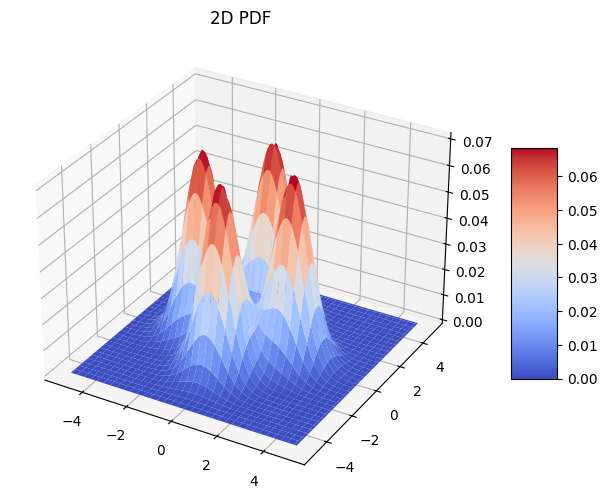

In [15]:
mu = 2
sigma = 0.75
x_p = np.linspace(-5, 5, 101)
y_p = np.linspace(-5, 5, 101)
x, y = np.meshgrid(x_p, y_p)
def pdf(x, y):
    nx = norm.pdf(x, mu, sigma)*norm.pdf(y, 0, sigma)+norm.pdf(x, -mu, sigma)*norm.pdf(y, 0, sigma)
    ny = norm.pdf(x, 0, sigma)*norm.pdf(y, mu, sigma)+norm.pdf(x, 0, sigma)*norm.pdf(y, -mu, sigma)
    return (nx+ny)/4
z = pdf(x, y)
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(x, y, z, cmap=cm.coolwarm)
ax.set_title('2D PDF')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

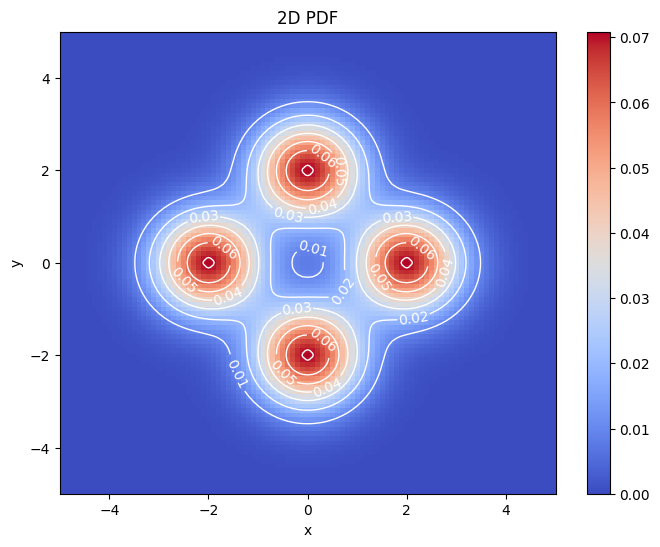

In [16]:
figure, ax = plt.subplots(figsize=(8, 6))
col = ax.pcolormesh(x, y, z, cmap=cm.coolwarm, vmin=z.min(), vmax=z.max(), shading='auto')
con = ax.contour(x, y, z, np.linspace(0, 0.07, 8), colors='white', linewidths=1)
ax.clabel(con, inline=1, fontsize=10)
ax.set_title('2D PDF')
ax.axis([x.min(), x.max(), y.min(), y.max()])
ax.set_xlabel('x')
ax.set_ylabel('y')
figure.colorbar(col)
plt.show()

La simmetria della distribuzione ci permette di dire subito che:
* $\mathbb{E}[x] = \mathbb{E}[y] = 0$

Va ora calcolato $\mathbb{E}[x^2]$ che sarà uguale a $\mathbb{E}[y^2]$ per la simmetria rispetto allo scambo $x\leftrightarrow y$

$\displaystyle\mathbb{E}[x^2] = \int x^2\,f(x,y)\,\mathrm{d}x\mathrm{d}y =$
 
$\displaystyle=\frac{1}{4}\int x^2\left[
g(x;\mu,\sigma)g(y, 0, \sigma) + 
g(x;-\mu,\sigma)g(y, 0, \sigma) + 
g(x;0,\sigma)g(y, \mu, \sigma) + 
g(x;0,\sigma)g(y, -\mu, \sigma)
\right]\,\mathrm{d}x\mathrm{d}y
$

Ingradando in $\mathrm{d}y$, possiamo usare la condizione di normalizzazione:

$\displaystyle \int g(y, \mu, \sigma)\,\mathrm{d}y = 1$

quindi:

$\displaystyle\mathbb{E}[x^2] =
\frac{1}{4}\int x^2\left[
g(x;\mu,\sigma) + 
g(x;-\mu,\sigma) + 
g(x;0,\sigma) + 
g(x;0,\sigma)
\right]\mathrm{d}x
$

Si può ricordare che $\mathbb{V}\mathrm{ar}[x] = \mathbb{E}[x^2] - \mathbb{E}[x]^2 = \sigma^2$.
Quindi, per una variabile $z$ normale, $\mathbb{E}[z^2] = \sigma^2+\mathbb{E}[z]^2$, dove $\mathbb{E}[z]$ sarà, nei tre casi, $\mu$, $0$ o $-\mu$. Quindi otterremo:

$\displaystyle\mathbb{E}[x^2] =
\frac{1}{4}\left[
(\sigma^2 + \mu^2) + 
(\sigma^2 + (-\mu)^2) + 
2\sigma^2
\right] = \sigma^2+\frac{\mu^2}{2} = \displaystyle\mathbb{E}[y^2]
$

Ora resta da calcolare $\mathbb{E}[xy]$:


$\displaystyle\mathbb{E}[xy] = \int xy\,f(x,y)\,\mathrm{d}x\mathrm{d}y =$

$\displaystyle=\frac{1}{4}\int xy\left[
g(x;\mu,\sigma)g(y, 0, \sigma) + 
g(x;-\mu,\sigma)g(y, 0, \sigma) + 
g(x;0,\sigma)g(y, \mu, \sigma) + 
g(x;0,\sigma)g(y, -\mu, \sigma)
\right]\,\mathrm{d}x\mathrm{d}y
$

Il calcolo si riduce a quello dei valori attesi di $x$ e $y$, vista la fattorizzazione di ciascuno dei quattro termini della PDF:

$\displaystyle\displaystyle\mathbb{E}[xy]=\frac{1}{4}\left[
\mu\cdot 0  -
\mu\cdot 0 + 
0\cdot \mu -
0\cdot \mu
\right] = 0
$

La covarianza tra $x$ e $y$ vale quindi:

$\mathbb{C}\mathrm{ov}(x,y) = \mathbb{E}[xy] - \mathbb{E}[x]\mathbb{E}[y] = 0$

Quindi $x$ e $y$ sono **scorrelate**. Ma è ovvio che **non sono indipendenti**. Se fossero indipendenti, potremmo scrivere $f(x,y)$ come il prodotto di due PDF, una funzione solo di $x$, l'altra funzione solo di $y$. Ma questo è evidentemente impossibile.

In generale, quindi, variabili scorrelate non sono necessariamente indipendenti.